In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df=pd.read_csv(r"D:\Data-Science\DATA Cleaning\loan-default-analysis\Data\loan_data.csv")

In [163]:
df.shape

(614, 13)

In [164]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [165]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [166]:
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_3592\332452315.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [167]:
num_cols=df.select_dtypes(include=np.number).columns
for num in num_cols:
    df[num].fillna(df[num].median(),inplace=True)


C:\Users\rohit\AppData\Local\Temp\ipykernel_3592\2574046072.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[num].fillna(df[num].median(),inplace=True)


In [168]:
# Zero income applicant
df[df['ApplicantIncome']==0].shape

(0, 13)

In [169]:
df['Loan_Staus']=df['Loan_Status'].str.strip().str.upper()

In [170]:
df['Loan_Status'].value_counts()
df['Loan_Status']=df['Loan_Status'].map({'Y':'Non-Default','N':'Default'})

In [171]:
df['Loan_Status']

0      Non-Default
1          Default
2      Non-Default
3      Non-Default
4      Non-Default
          ...     
609    Non-Default
610    Non-Default
611    Non-Default
612    Non-Default
613        Default
Name: Loan_Status, Length: 614, dtype: object

Text(0.5, 1.0, 'Loan Default distribution')

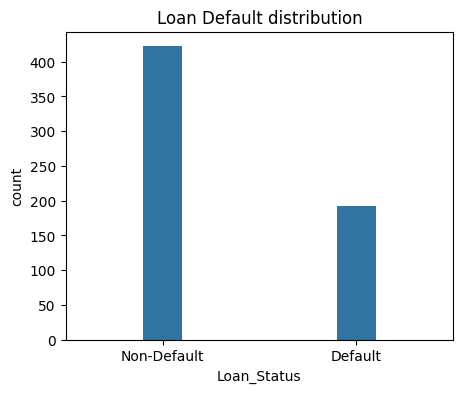

In [172]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='Loan_Status',width=0.2)
plt.title('Loan Default distribution')

# Observation:
### Dataset is imbalanced (more Given loan than Non given loan)

In [173]:
df['Credit_History'].astype(int)

0      1
1      1
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Credit_History, Length: 614, dtype: int64

Text(0.5, 1.0, 'Credit History vs Loan Status')

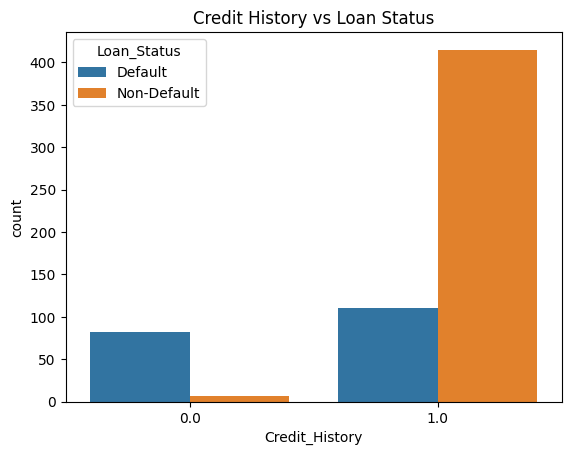

In [174]:
sns.countplot(data=df,x='Credit_History',hue='Loan_Status')
plt.title("Credit History vs Loan Status")

## credit history strongly affects loan approval.

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

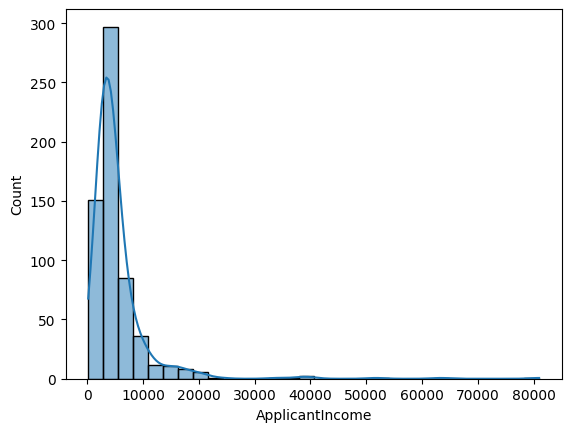

In [175]:
sns.histplot(df['ApplicantIncome'],bins=30,kde=True)

## Income is right-skewed
## Few high-income applicants

# 4. Applicant Income vs Loan Status

Text(0.5, 1.0, 'Income vs Loan Status')

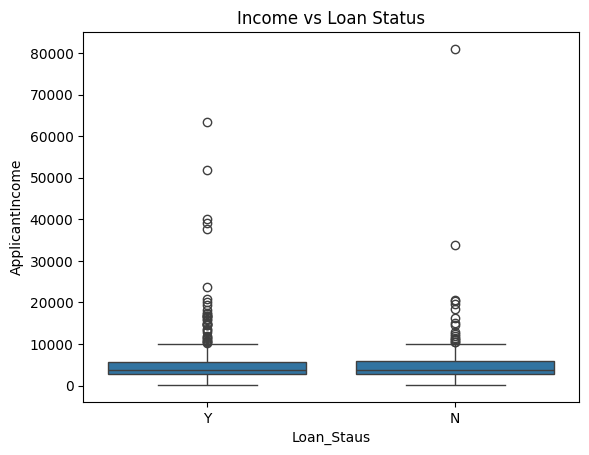

In [176]:
sns.boxplot(data=df,x='Loan_Staus',y='ApplicantIncome')
plt.title("Income vs Loan Status")

## People with lower income are more likely to have their loan rejected.

In [177]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Loan_Staus           0
dtype: int64

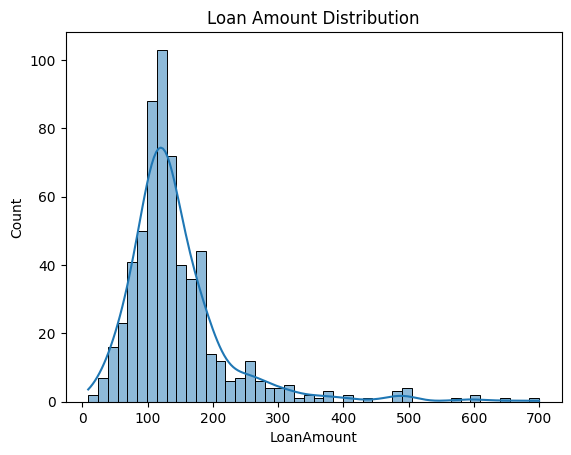

In [178]:
# Loan ammount Distribution
sns.histplot(df['LoanAmount'],kde=True)
plt.title("Loan Amount Distribution")
plt.show()


<Axes: xlabel='Loan_Staus', ylabel='LoanAmount'>

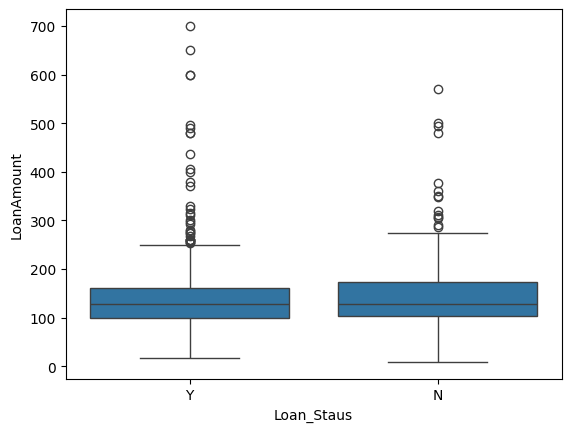

In [179]:
#Loan amount vs Loan Status
sns.boxplot(data=df,x='Loan_Staus',y='LoanAmount')

##  approved Loan is higher than rejected

<Axes: xlabel='Self_Employed', ylabel='count'>

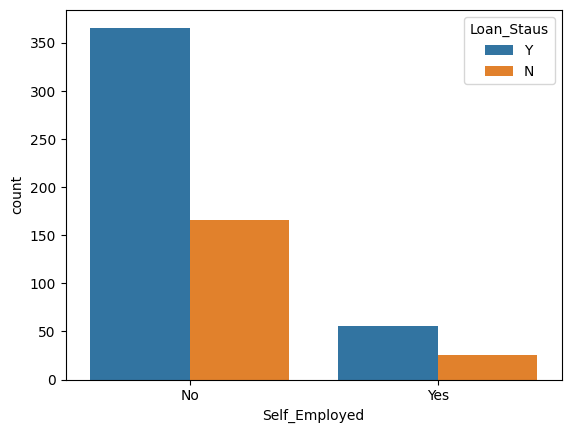

In [183]:
# Employee Type vs LOan_Status
sns.countplot(data=df,x='Self_Employed',hue='Loan_Staus')

## Self-employed applicants show slightly higher risk

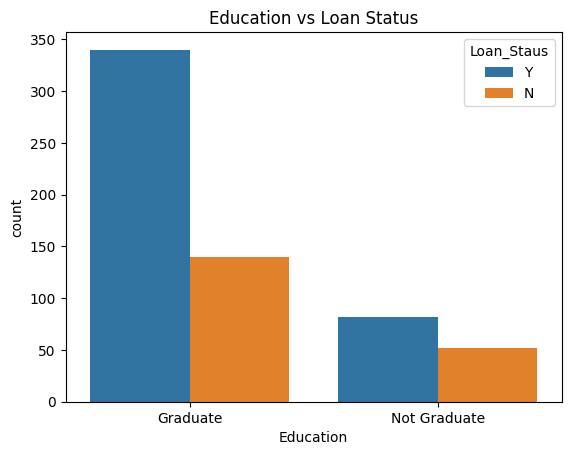

In [187]:
sns.countplot(data=df,x='Education',hue='Loan_Staus')
plt.title("Education vs Loan Status")
plt.show()

## Graduates have marginally better repayment behavior

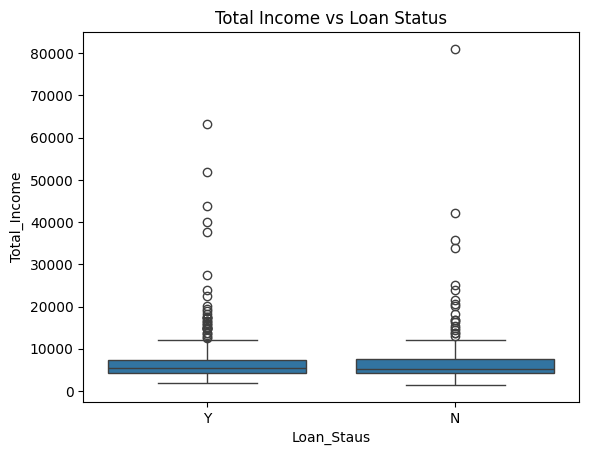

In [189]:
# Feature Engineering: Total Income
df['Total_Income']=df['ApplicantIncome']+df['CoapplicantIncome']
sns.boxplot(data=df,x='Loan_Staus',y='Total_Income')
plt.title("Total Income vs Loan Status")
plt.show()

In [181]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Loan_Staus           0
dtype: int64